In [1]:
import os
import sys

sys.path.append("/home/koledjoz/Ex2VecExtended")

In [2]:
import torch
import numpy as np
import pandas as pd
from tqdm import tqdm
import json

In [3]:
df = pd.read_parquet('../../../../sorted_data.parquet')
max_history = 3500
user_count = df['user_id'].max()
item_count = df['track_id'].max()

In [4]:
pos = df.groupby('user_id').cumcount().to_numpy()
users = df['user_id'].to_numpy()
tracks = df['track_id'].to_numpy()
times = df['ts'].to_numpy()

time_history = np.zeros((user_count + 1, max_history), dtype=times.dtype)
item_history = np.zeros((user_count + 1, max_history), dtype=tracks.dtype)

mask = pos < max_history  # safeguard if some users exceed max_history

item_history[users[mask], pos[mask]] = tracks[mask]
time_history[users[mask], pos[mask]] = times[mask]

In [5]:
class DatasetWrapper(torch.utils.data.Dataset):
    def __init__(self, predict_dict, start_time, end_time, n_steps):
        self.times = []
        self.users = []
        self.items = []

        for u, vals in predict_dict.items():
            for i in vals:
                for t in np.linspace(start_time, end_time, n_steps):
                    self.times.append(int(t))
                    self.users.append(int(u))
                    self.items.append(int(i))
        

    def __len__(self):
        return len(self.times)

    def __getitem__(self, idx):
        return self.times[idx], self.users[idx], self.items[idx]

In [6]:
with open('../../../../split_data/test/test_dict.json', 'r') as f:
    predict_dict = json.load(f)

In [7]:
dataset = DatasetWrapper(predict_dict, 1654041600, 1661990376, 500)

In [8]:
batch_size = 2**17
batch_size

131072

In [9]:
checkpoint_path = "../train_notebooks/original.pt"
checkpoint = torch.load(checkpoint_path, map_location="cpu", weights_only=False)

In [10]:
checkpoint['config']

{'n_users': np.int64(13209), 'n_items': np.int64(3027), 'latent_d': 64}

In [11]:
from src.models.optimized.original import Ex2VecOriginalFast

device = 'cuda'
config = checkpoint['config']


model = Ex2VecOriginalFast(config)
model.load_state_dict(checkpoint["model_state_dict"], strict=False)
model.initialize_histories(torch.tensor(item_history).to(device), torch.tensor(time_history).to(device))
model.to(device)

Ex2VecOriginalFast(
  (user_lamb): Embedding(13210, 1)
  (user_bias): Embedding(13210, 1)
  (item_bias): Embedding(3028, 1)
  (embedding_user): Embedding(13210, 64)
  (embedding_item): Embedding(3028, 64)
  (logistic): Sigmoid()
)

In [12]:
from torch.utils.data import DataLoader

data_list = []

prediction_cols = [f"item_{i + 1}" for i in range(3028)]

with torch.no_grad():
    model.eval()
    dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=False)
    for step, batch in enumerate(tqdm(dataloader)):
        model_result = model(batch[0].to(device), batch[1].to(device))
        
        user_id = batch[1].cpu().numpy()
        # item_ids = np.array([predict_dict[str(x)] for x in user_id])
        item_ids = batch[2].cpu().numpy()
        ts = batch[0].cpu().numpy()
        
        score = np.take_along_axis(model_result[:, 1:].cpu().numpy(), item_ids[:, None] - 1, axis=1)

        prob = np.take_along_axis(torch.nn.Softmax(dim=1)(model_result[:, 1:]).cpu().numpy(), item_ids[:, None] - 1, axis=1)


        u = user_id.reshape(-1)[:, None]  # -> (B, 1)
        i = item_ids.reshape(-1)[:, None]  # -> (B, 1)
        t = ts.reshape(-1)[:, None]  # -> (B, 1)


        data_list.append(np.concatenate([u, i, t, prob, score], axis=1))



    df = pd.DataFrame(np.concatenate(data_list), columns=['user', 'item', 'ts', 'prob', 'score'])
    df = (
        df.sort_values("ts")  # ensure scores are in time order
        .groupby(["user", "item"])  # group by user & item
        .agg({
            "score": list,
            "prob": list
        })  # collect ordered scores
        .reset_index()
    )


100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 101/101 [10:44<00:00,  6.38s/it]


In [13]:
output_path = './curves/original_predictions_for_curves.csv'

df.to_csv(output_path, index=False)

In [14]:
import matplotlib.pyplot as plt

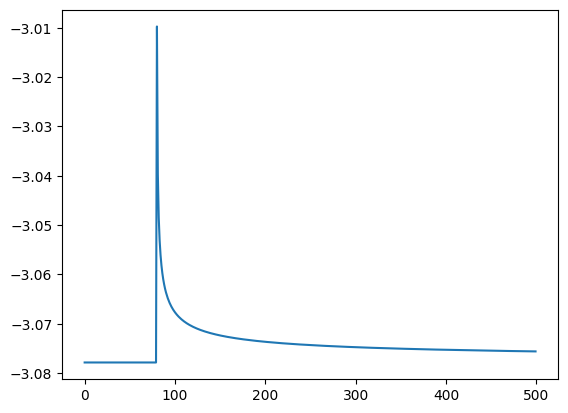

In [15]:
plt.plot(df.iloc[0, 2])